In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
    df = pd.read_csv("../DataSets/LP_Train.csv")

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## 1. Data Exploration

### Descriptive statistics help uncover the central tendency and spread of numeric data (mean, median, std. dev.). For example, skewed distributions in ApplicantIncome may indicate the need for transformation.

In [6]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [7]:
df.Dependents.unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [8]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


In [10]:
df.Gender=df.Gender.fillna("Male")

In [11]:
df.Married=df.Married.fillna("Yes")

In [12]:
df.Dependents=df.Dependents.fillna(0)

In [13]:
df.Self_Employed=df.Self_Employed.fillna("No")

In [14]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [15]:
df.LoanAmount=df.LoanAmount.fillna(146.41)

In [16]:
df.Loan_Amount_Term=df.Loan_Amount_Term.fillna(342)

In [17]:
df.Credit_History=df.Credit_History.fillna(0.84)

In [18]:
df.Dependents=df.Dependents.replace('[3+]','3',regex=True).astype('int64')

# 2. Demographic Analysis

## Loan Approval Rate by Gender

#### Males may be more likely to apply, but approval rates should be compared on a percentage basis.

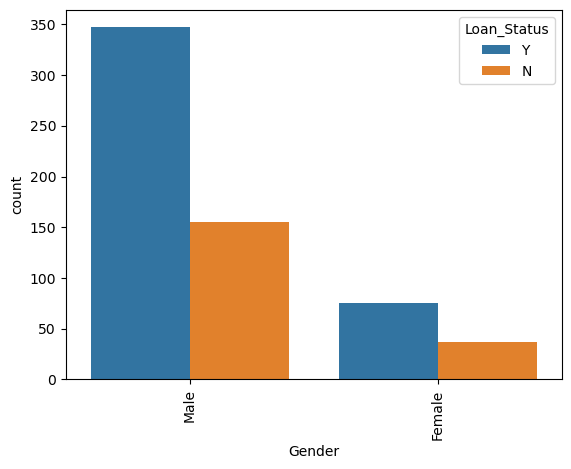

In [22]:
sb.countplot(x=df.Gender,hue=df.Loan_Status)
plt.xticks(rotation=90)
plt.show()

In [23]:
pd.crosstab(index=df.Gender,columns=df.Loan_Status,margins=True)

Loan_Status,N,Y,All
Gender,,,
Female,37,75,112
Male,155,347,502
All,192,422,614


## Loan Approval Distribution by Marital Status

#### Married applicants might have higher approval due to dual income or perceived stability.

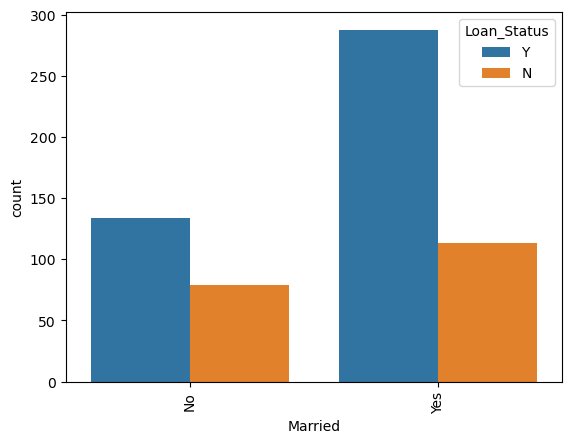

In [42]:
sb.countplot(x=df.Married,hue=df.Loan_Status)
plt.xticks(rotation=90)
plt.show()

In [44]:
df.Married.unique()

array(['No', 'Yes'], dtype=object)

## Loan Approval Rate by Number of Dependents

#### More dependents may suggest greater financial burden, potentially lowering approval chances.

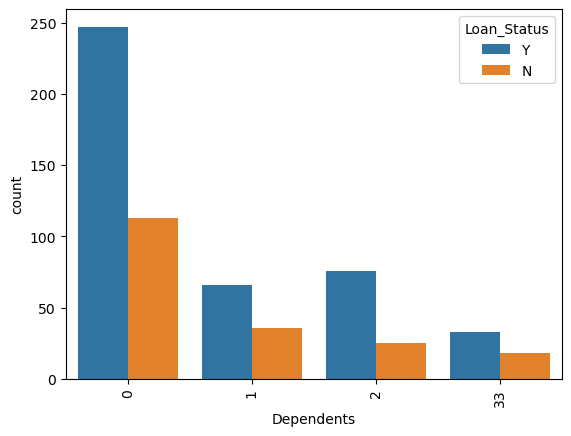

In [48]:
sb.countplot(x=df.Dependents,hue=df.Loan_Status)
plt.xticks(rotation=90)
plt.show()

## Loan Approval by Education Level

#### Graduates could be viewed as more creditworthy, affecting approval likelihood. 

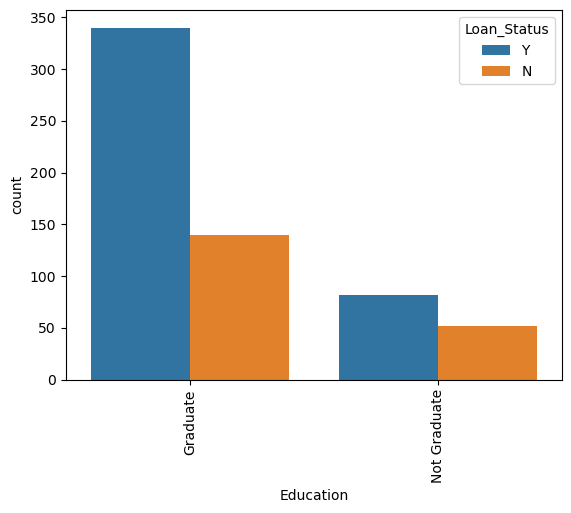

In [54]:
sb.countplot(x=df.Education,hue=df.Loan_Status)
plt.xticks(rotation=90)
plt.show()

## Loan Approval Rate: Employed vs Self-Employed

#### Self-employed individuals may face stricter credit checks.

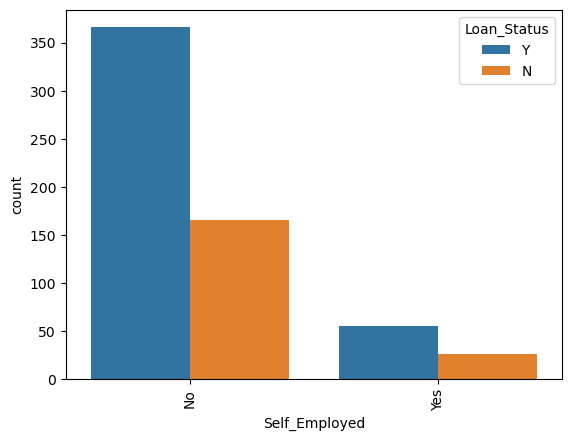

In [58]:
sb.countplot(x=df.Self_Employed,hue=df.Loan_Status)
plt.xticks(rotation=90)
plt.show()

# 3. Income and Loan Amount Analysis

In [62]:
y=df[df.Loan_Status=='Y']
y

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.41,360.0,1.0,Urban,Y
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.00,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.00,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.00,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.00,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.00,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.00,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,33,Graduate,No,4106,0.0,40.00,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.00,360.0,1.0,Urban,Y


## Applicant Income vs Loan Approval 

#### Higher income generally correlates with higher approval, but outliers and non-linear effects are common.

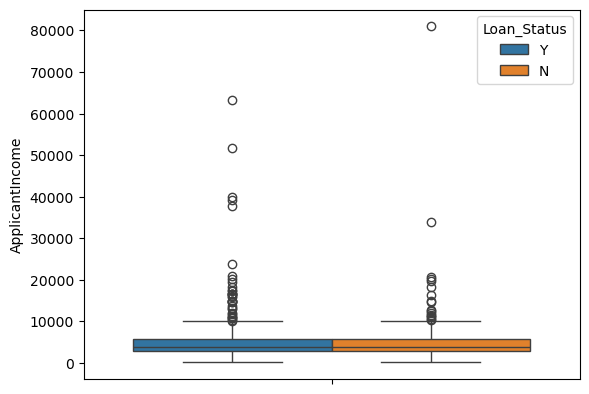

In [66]:
sb.boxplot(y=df.ApplicantIncome,hue=df.Loan_Status)
plt.show()

## Coapplicant Income vs Loan Approval

#### Adds to repayment capacity but may have lower impact than primary income.

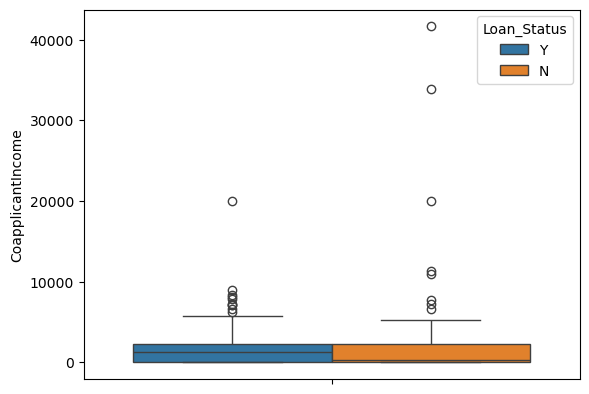

In [70]:
sb.boxplot(y=df.CoapplicantIncome,hue=df.Loan_Status)
plt.show()

## Correlation Heatmap: Income and Loan Amount

 #### Correlations reveal strength of association between income types and loan amounts.

In [74]:
xy=df[['ApplicantIncome','CoapplicantIncome','LoanAmount']].corr()

In [76]:
print(xy)

                   ApplicantIncome  CoapplicantIncome  LoanAmount
ApplicantIncome           1.000000          -0.116605    0.565620
CoapplicantIncome        -0.116605           1.000000    0.187829
LoanAmount                0.565620           0.187829    1.000000


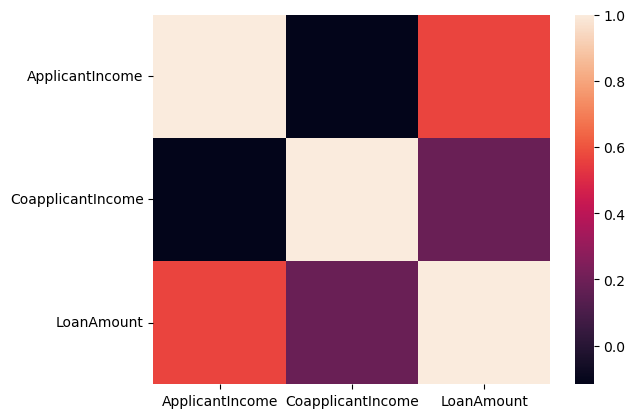

In [78]:
sb.heatmap(xy)
plt.show()

# 4.Credit History and Loan Term Analysis

## Loan Approval Rate by Credit History

#### Applicants with a positive history are far more likely to be approved.

In [83]:
df.groupby('Loan_Status')['Credit_History'].sum()

Loan_Status
N    107.92
Y    409.08
Name: Credit_History, dtype: float64

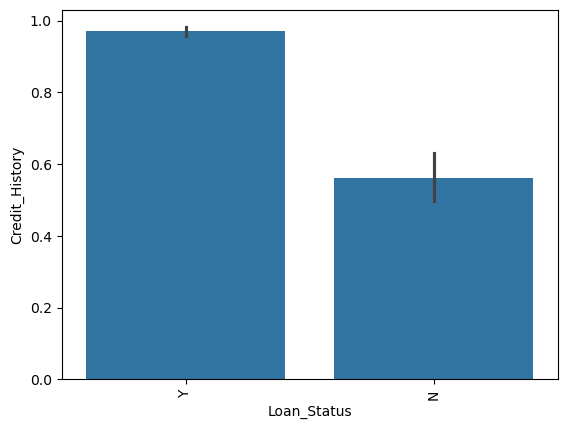

In [85]:
sb.barplot(x=df.Loan_Status,y=df.Credit_History)
plt.xticks(rotation=90)
plt.show()

## Loan Term vs Loan Approval

#### Shorter terms may be riskier, affecting approval.

In [89]:
df.groupby('Loan_Status')['Loan_Amount_Term'].mean()

Loan_Status
N    344.000000
Y    341.090047
Name: Loan_Amount_Term, dtype: float64

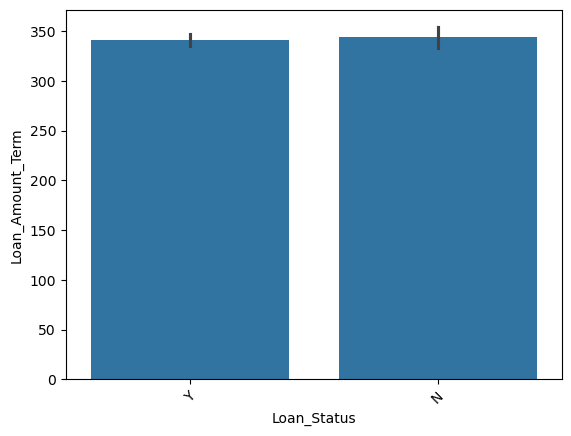

In [91]:
sb.barplot(x=df.Loan_Status,y=df.Loan_Amount_Term)
plt.xticks(rotation=45)
plt.show()

## Credit History vs Loan Term Interaction on Approval

#### Examining these together can show conditional patterns.

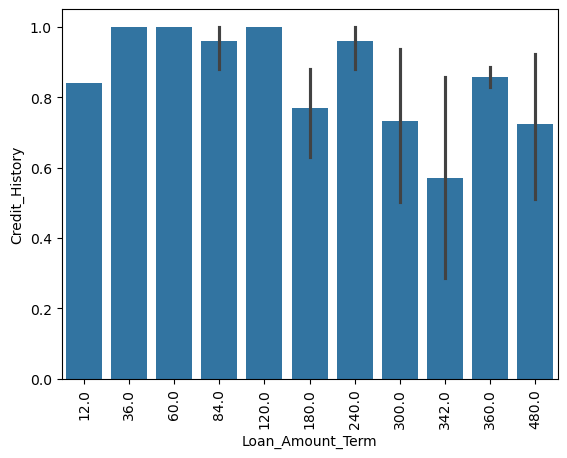

In [95]:
sb.barplot(x=df.Loan_Amount_Term,y=df.Credit_History)
plt.xticks(rotation=90)
plt.show()

# 5. Property Area and Loan Approval

## Loan Approval by Property Area (Urban, Semiurban, Rural)

#### Approval rates vary by area, possibly reflecting risk assessments or property value.

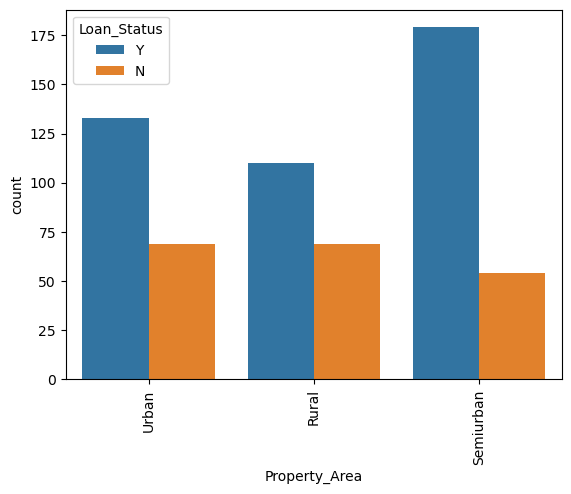

In [100]:
sb.countplot(x=df.Property_Area,hue=df.Loan_Status	)
plt.xticks(rotation=90)
plt.show()